<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Unique Pclass values: [3 1 2]
Unique Sex values: ['male' 'female']
Unique Embarked values: ['S' 'C' 'Q' nan]
                 Age          Fare       SibSp       Parch
sum     21205.170000  28693.949300  466.000000  340.000000
max        80.000

C:\Users\BC\AppData\Local\Temp\ipykernel_18864\153251279.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='coolwarm')


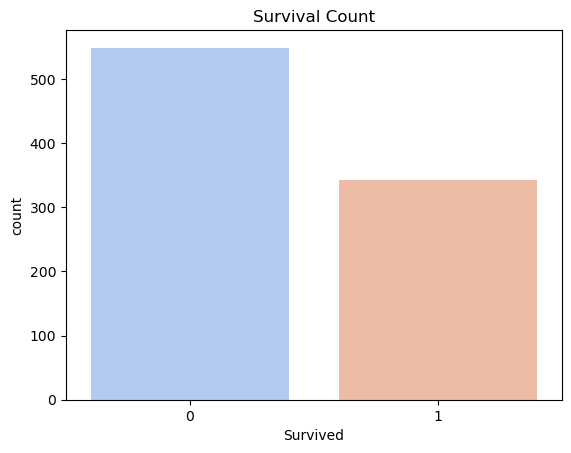

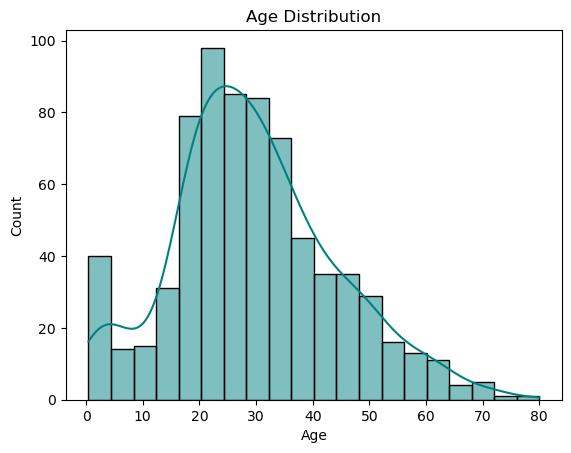

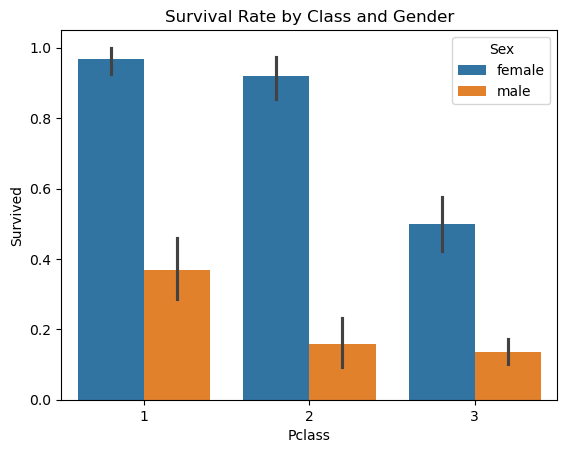

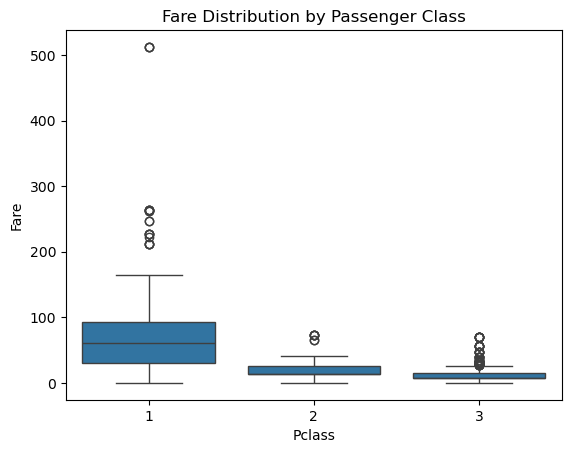


INSIGHTS:
1. About 62% of passengers did not survive.
2. Women had a much higher survival rate than men.
3. 1st class passengers had better survival chances.
4. Average passenger age ≈ 30 years.
5. Fares vary widely; 1st class paid the most.
6. Missing values in 'Age' and 'Cabin' need cleaning.



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv("Titanic-Dataset.csv")
df.info()
df.head()
#searching 
top_10=df.head(10)
age_over_50 = df[df['Age']>50]
female_survivors = df[(df['Sex'] == 'female') & (df['Survived'] == 1)]
# Unique values for each categorical column
print("Unique Pclass values:", df['Pclass'].unique())
print("Unique Sex values:", df['Sex'].unique())
print("Unique Embarked values:", df['Embarked'].unique())
# Apply all aggregations
agg_summary = df[['Age', 'Fare', 'SibSp', 'Parch']].agg([
    'sum', 'max', 'min', 'count', 'mean', 'median', 'std'
])
print(agg_summary)
# Count of survivors
sns.countplot(data=df, x='Survived', palette='coolwarm')
plt.title("Survival Count")
plt.show()

# Age distribution
sns.histplot(df['Age'], bins=20, kde=True, color='teal')
plt.title("Age Distribution")
plt.show()

# Survival by class and gender
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title("Survival Rate by Class and Gender")
plt.show()

# Fare distribution by class
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title("Fare Distribution by Passenger Class")
plt.show()
print("""
INSIGHTS:
1. About 62% of passengers did not survive.
2. Women had a much higher survival rate than men.
3. 1st class passengers had better survival chances.
4. Average passenger age ≈ 30 years.
5. Fares vary widely; 1st class paid the most.
6. Missing values in 'Age' and 'Cabin' need cleaning.
""")




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
5   6          

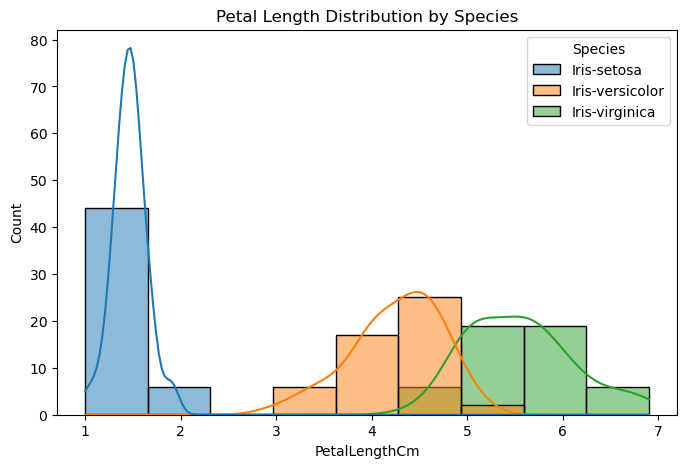

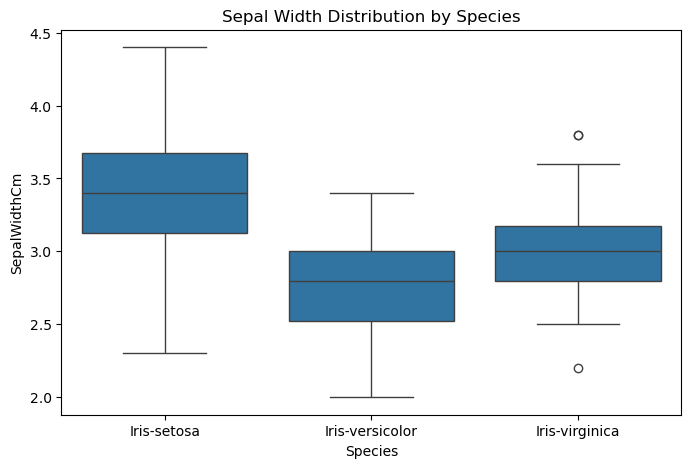

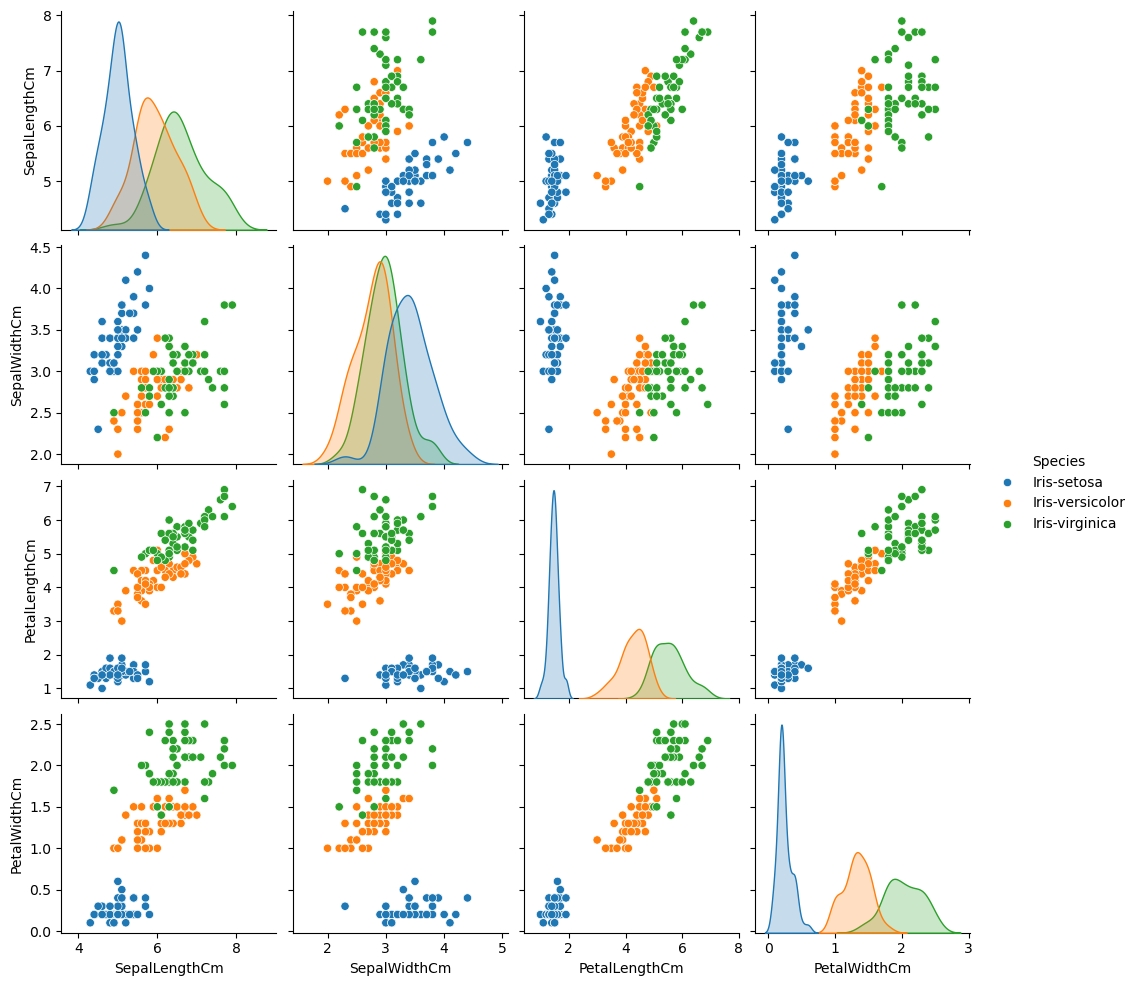


📊 INTERPRETATION:
- The dataset contains 150 samples and 3 species: Iris-setosa, Iris-versicolor, and Iris-virginica.
- Each species has 50 samples — the data is balanced.
- Petal features (length & width) vary significantly among species, while sepal features overlap more.
- 'Iris-setosa' has distinctly smaller petal dimensions than the other two species.
- Aggregations show that Virginica has the highest averages, Setosa the lowest.
- Visuals confirm petal features separate species clearly, explaining why this dataset is perfect for classification.



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Iris.csv") 
print(df.info())
print(df.head(10))
filtered = df[df['SepalLengthCm'] > 5.0]
print(filtered.head())
print("\n===== Filter: Species == 'Iris-setosa' =====")
filtered_setosa = df[df['Species'] == 'Iris-setosa']
print(filtered_setosa.head())
print(df['Species'].unique())
print(df['Species'].value_counts())
numeric_cols = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
agg_funcs = ['sum','max','min','count','mean','median','std']
summary = df[numeric_cols].agg(agg_funcs)
print(summary)
# Mode (most frequent values)
modes = df[numeric_cols].mode().iloc[0]
print(modes)
# 6️Visualization (Seaborn & Matplotlib)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='PetalLengthCm', hue='Species', kde=True)
plt.title("Petal Length Distribution by Species")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Species', y='SepalWidthCm')
plt.title("Sepal Width Distribution by Species")
plt.show()
sns.pairplot(df, hue='Species', vars=numeric_cols)
plt.show()
# 7️⃣ Interpretation
print("""
📊 INTERPRETATION:
- The dataset contains 150 samples and 3 species: Iris-setosa, Iris-versicolor, and Iris-virginica.
- Each species has 50 samples — the data is balanced.
- Petal features (length & width) vary significantly among species, while sepal features overlap more.
- 'Iris-setosa' has distinctly smaller petal dimensions than the other two species.
- Aggregations show that Virginica has the highest averages, Setosa the lowest.
- Visuals confirm petal features separate species clearly, explaining why this dataset is perfect for classification.
""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

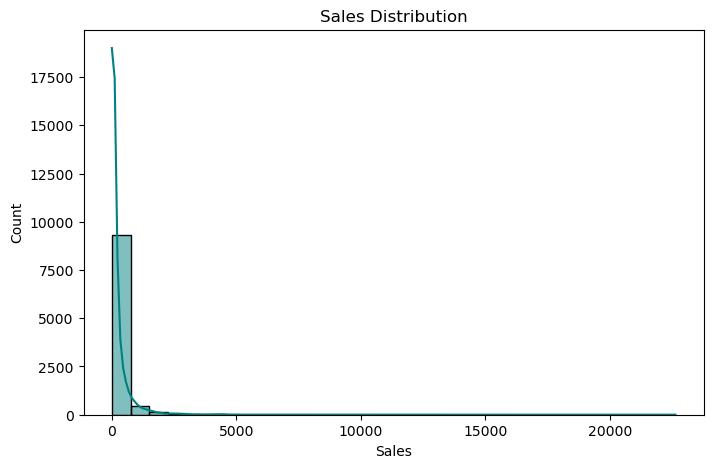

C:\Users\BC\AppData\Local\Temp\ipykernel_13192\2802637661.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='coolwarm')


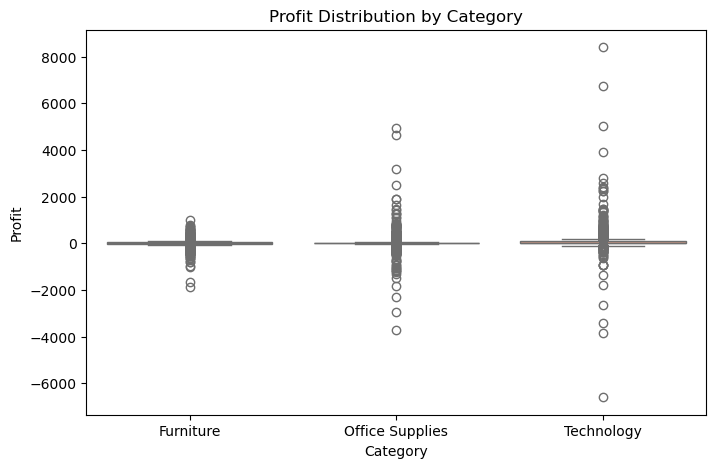

C:\Users\BC\AppData\Local\Temp\ipykernel_13192\2802637661.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Sub-Category', y='Sales', estimator='sum', ci=None)


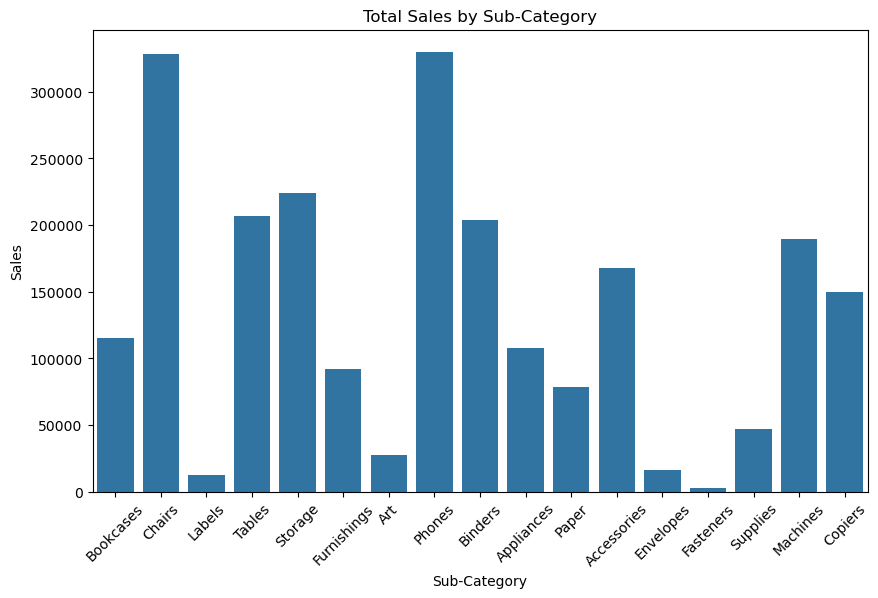

C:\Users\BC\AppData\Local\Temp\ipykernel_13192\2802637661.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Region', y='Profit', estimator='sum', ci=None)


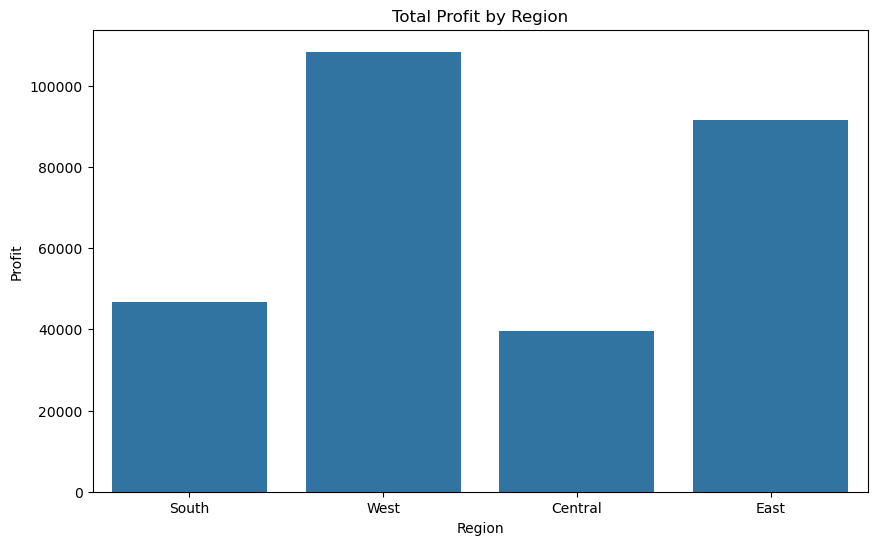


📊 INTERPRETATION:

1. The dataset contains sales records across multiple U.S. states, categories, and regions.
2. There are three main product categories: Furniture, Office Supplies, and Technology.
3. Technology generally gives higher average profits, while Furniture has lower margins and frequent losses.
4. Some orders show negative profit due to high discounts.
5. California and New York are among the top-performing states in terms of total sales.
6. Average Sales ≈ (summary.loc['mean', 'Sales']:.2f) USD and average Profit ≈ (summary.loc['mean', 'Profit']:.2f) USD.
7. Visuals show that "Chairs" and "Phones" dominate sales volume.
8. Aggregations and visual trends reveal that discount management directly affects profitability.



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#encode is liye apply hua q k file jis format thi panda usko read nhi kr rha tha isliye usko encode kiya
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
print(df.info())
print(df.head(10))
top_10_sales = df.nlargest(10, 'Sales')
print(top_10_sales[['Category', 'Sub-Category', 'Sales', 'Profit']])
loss_cases = df[df['Profit'] < 0]
print(loss_cases.head())
california_data = df[df['State'] == 'California']
df['Category'].unique()
df['Sub-Category'].unique()
df['State'].nunique()
numeric_cols = ['Sales','Quantity','Discount','Profit']
agg_funcs = ['sum','max','min','count','mean','median','std']
summary = df[numeric_cols].agg(agg_funcs)
print(summary)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Sales', bins=30, kde=True, color='teal')
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Category', y='Profit', palette='coolwarm')
plt.title("Profit Distribution by Category")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Sub-Category', y='Sales', estimator='sum', ci=None)
plt.title("Total Sales by Sub-Category")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Profit', estimator='sum', ci=None)
plt.title("Total Profit by Region")
plt.show()
print("""
📊 INTERPRETATION:

1. The dataset contains sales records across multiple U.S. states, categories, and regions.
2. There are three main product categories: Furniture, Office Supplies, and Technology.
3. Technology generally gives higher average profits, while Furniture has lower margins and frequent losses.
4. Some orders show negative profit due to high discounts.
5. California and New York are among the top-performing states in terms of total sales.
6. Average Sales ≈ (summary.loc['mean', 'Sales']:.2f) USD and average Profit ≈ (summary.loc['mean', 'Profit']:.2f) USD.
7. Visuals show that "Chairs" and "Phones" dominate sales volume.
8. Aggregations and visual trends reveal that discount management directly affects profitability.
""")